# Zonal means come for free

Grouping a floating point coordinate is normally a mistake. You bin, you
argue about bin edges, and you accept that the answer depends on the
argument.

On a HEALPix grid you do not have to, because latitude is not continuous
here. The grid is built as a stack of rings of constant latitude, and a map
of level `k` has exactly `4 * 2**k - 1` of them. Every cell sits on one
ring, every cell on a ring shares a latitude to the last bit, and every cell
has the same area. A zonal mean is therefore a group-by over a genuinely
discrete coordinate, and it is exact.

*The figure is saved with this notebook. Run the cells in order, from the top, to compute it again. The same example on the web: [Zonal means come for free](https://waterpark.dkrz.de/docs/examples/04_zonal_mean/).*

## The rings

Count them first. The number is a property of the level, so it is a good
check that you are holding the grid you think you are.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

URL = "s3://reanalysis/healpix/era5/P1M/level_7.zarr"
S3 = {"anon": True, "endpoint_url": "https://s3.waterpark.dkrz.de"}

ds = xr.open_zarr(URL, storage_options=S3, chunks=None)
level = ds.attrs["healpix_level"]
latitude = ds["latitude"].values

# Rounding is defensive rather than approximate. It collapses the last bit
# or two of floating point noise in a coordinate array that was computed
# elsewhere; it cannot merge rings, which are far further apart than that.
_, rings = np.unique(np.round(latitude, 8), return_inverse=True)

print(f"level {level}: {rings.max() + 1} rings, expected {4 * 2**level - 1}")

Three lines and no library. That is the whole mechanism.

## Two months

In [ ]:
field = ds["tas"].sel(time=slice("2021-01", "2021-07")).isel(time=[0, -1]).load()
field = field.assign_coords(ring=("cell", rings))

zonal = field.groupby("ring").mean()
ring_lat = (
    xr.DataArray(latitude, dims="cell")
    .groupby(xr.DataArray(rings, dims="cell"))
    .first()
    .values
)

No weights again. Every cell on a ring has the same area *and* the same
latitude, so the plain mean along the ring is the zonal mean, full stop.

## The catch worth knowing

Rings do not all hold the same number of cells. In the polar caps the ring
at index `i` holds `4 * i` cells; in the equatorial belt every ring holds
`4 * nside`. That does not affect any single zonal mean, but it does mean
the profile is not interchangeable with the field: average the profile
over latitude and you will not get the global mean back, because you would
be counting a four-cell polar ring as heavily as a five-hundred-cell
equatorial one.

In [ ]:
counts = np.bincount(rings)
july = zonal.isel(time=1).values

print(f"unweighted profile mean {np.mean(july):.2f} K")
print(f"weighted by cells/ring  {np.average(july, weights=counts):.2f} K")
print(f"mean over all cells     {float(field.isel(time=1).mean()):.2f} K")

## The plot

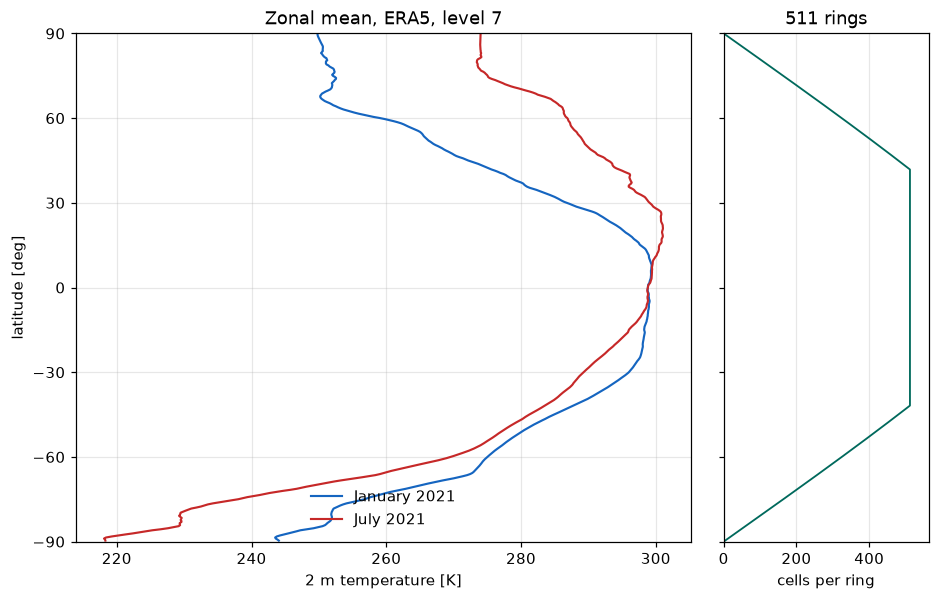

In [ ]:
fig, (ax, ax_counts) = plt.subplots(
    1,
    2,
    figsize=(10, 6),
    sharey=True,
    gridspec_kw={"width_ratios": [3, 1], "wspace": 0.08},
)

for index, (name, colour) in enumerate([("January", "#1565c0"), ("July", "#c62828")]):
    ax.plot(
        zonal.isel(time=index).values,
        ring_lat,
        color=colour,
        lw=1.4,
        label=f"{name} 2021",
    )

ax.set_xlabel("2 m temperature [K]")
ax.set_ylabel("latitude [deg]")
ax.set_yticks(np.arange(-90, 91, 30))
ax.set_ylim(-90, 90)
ax.grid(alpha=0.3)
ax.legend(frameon=False, loc="lower center")
ax.set_title(f"Zonal mean, ERA5, level {level}")

ax_counts.plot(counts, ring_lat, color="#00695c", lw=1.2)
ax_counts.set_xlim(0, counts.max() * 1.1)
ax_counts.set_xlabel("cells per ring")
ax_counts.grid(alpha=0.3, axis="x")
ax_counts.set_title(f"{rings.max() + 1} rings")

fig.savefig("04_zonal_mean.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

## Nothing was approximated

It is worth noticing what has not happened. There was no remapping to a
regular grid, no choice of target resolution, no interpolation weights,
and no bin edges to defend in review. The profile on the left is the data
rearranged, not the data resampled.

The same holds if the store was written against an ellipsoidal HEALPix
definition rather than a spherical one. That changes the latitude of each
ring, since the mapping is a function of latitude alone, but it does not
split a ring or move a cell onto a different one. The grouping stays exact
either way.

The right-hand panel is the trapezoid you would have had to integrate by
hand on a lon/lat grid, drawn out. It is also why the polar ends of the
profile are noisier: the outermost rings average four cells, not five
hundred.